In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

import sys

sys.path.insert(0, "../utils")

from modules import create_grid
from plots import *
from string_handling import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [2]:
shapefile_path = "../../../Shapefiles/Cameroon Shapefiles/new/"

In [3]:
cameroon_extnord_gdf = gpd.read_file(f"{shapefile_path}ExtremeNord_region_Level0.shp",  encoding=enc)

In [4]:
cameroon_extnord_gdf.head()

,GID_1,GID_0,Pays,Nom_Region,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,CMR.4_1,CMR,Cameroon,Extrême-Nord,Extreme-North,NA,Région,Region,NA,CM.EN,NA,"POLYGON ((15.49626 10.12337, 15.49885 10.11941..."


In [5]:
cameroon_extnord_gdf = cameroon_extnord_gdf.to_crs(epsg=4326)
cameroon_extnord_gdf.drop(columns=['GID_1','GID_0','Pays','VARNAME_1','NL_NAME_1','TYPE_1','ENGTYPE_1','CC_1',
                           'HASC_1','ISO_1'], inplace = True)
cameroon_extnord_gdf.rename(columns={"Nom_Region" : "GID0"}, inplace = True)
cameroon_extnord_gdf['GID0'] = cameroon_extnord_gdf['GID0'].str.lower()
cameroon_extnord_gdf['GID0'] = cameroon_extnord_gdf['GID0'].apply(lambda x : remove_accents(x))

In [6]:
cameroon_extnord_gdf.head()

,GID0,geometry
0,extreme-nord,"POLYGON ((15.49626 10.12337, 15.49885 10.11941..."


<Axes: >

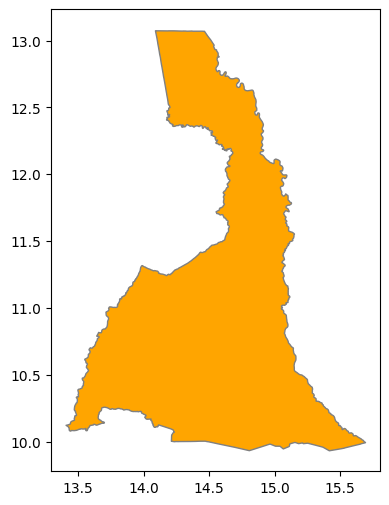

In [7]:
cameroon_extnord_gdf.plot(facecolor="none", edgecolor='grey', figsize=(6,6), color='orange')

In [8]:
cameroon_extnord_lv3 = gpd.read_file(f"{shapefile_path}ExtremeNord_region_Level3.shp",  encoding=enc)

In [9]:
cameroon_extnord_lv3.head()

,OBJECTID,Nom_AS,Code_AS,District_S,Code_DS,Nom_Arrond,Code_Arron,Nom_Dept,Code_Dept,Nom_Region,Code_Reg,Id_Arrond,Pays,Code_RS,Id_DS,AVS,Autre_nom,Eff_AVS,Noms_AVS,A_statuer,No_decret,Date_creat,TITRE,Superficie,geometry
0,698,Damaï,09MTW01,Moutourwa,MTW,Moutourwa,09 04 05,Mayo-Kani,09 04,Extreme Nord,09,A245,Cameroun,EXT,133,None,None,0,None,None,None,None,DAMAÏ,188895834.0,"POLYGON ((14.15799 10.36594, 14.15803 10.36582..."
1,699,Moutourwa,09MTW04,Moutourwa,MTW,Moutourwa,09 04 05,Mayo-Kani,09 04,Extreme Nord,09,A245,Cameroun,EXT,133,None,None,0,None,None,None,None,MOUTOURWA,79680340.0,"POLYGON ((14.07453 10.23127, 14.07441 10.23108..."
2,701,Werfeo,09KAR13,Kar Hay,KAR,Tchatibali,09 03 10,Mayo-Danay,09 03,Extreme Nord,09,A326,Cameroun,EXT,80,None,None,0,None,None,None,None,WERFEO,145385776.0,"POLYGON ((14.83493 9.94595, 14.83488 9.94604, ..."
3,702,Guissia,09KAR08,Kar Hay,KAR,Kar Hay,09 03 02,Mayo-Danay,09 03,Extreme Nord,09,A153,Cameroun,EXT,80,None,None,0,None,None,None,None,GUISSIA,76533476.0,"POLYGON ((14.99149 10.08522, 14.99149 10.08532..."
4,703,Tchatibali,09KAR12,Kar Hay,KAR,Tchatibali,09 03 10,Mayo-Danay,09 03,Extreme Nord,09,A326,Cameroun,EXT,80,None,None,0,None,None,None,None,TCHATIBALI,59800615.0,"POLYGON ((14.94005 10.06340, 14.94025 10.06339..."


In [10]:
cameroon_extnord_lv3 = cameroon_extnord_lv3.to_crs(epsg=4326)
cameroon_extnord_lv3.drop(columns=['OBJECTID','Code_AS','Code_DS','Nom_Arrond','Code_Arron','Code_Dept','Code_Reg','Id_Arrond',
                           'Pays','Code_RS','Id_DS','AVS','Autre_nom', 'Eff_AVS', 'Noms_AVS', 'A_statuer', 'No_decret',
                            'Date_creat', 'TITRE', 'Superficie'], inplace = True)
cameroon_extnord_lv3.rename(columns={"Nom_AS": "GID3", "District_S": "GID2", "Nom_Dept": "GID1", "Nom_Region" : "GID0"}, inplace = True)
cameroon_extnord_lv3['GID0'] = cameroon_extnord_lv3['GID0'].str.lower()
cameroon_extnord_lv3['GID0'] = cameroon_extnord_lv3['GID0'].apply(lambda x : remove_accents(x))
cameroon_extnord_lv3['GID1'] = cameroon_extnord_lv3['GID1'].str.lower()
cameroon_extnord_lv3['GID1'] = cameroon_extnord_lv3['GID1'].apply(lambda x : remove_accents(x))
cameroon_extnord_lv3['GID2'] = cameroon_extnord_lv3['GID2'].str.lower()
cameroon_extnord_lv3['GID2'] = cameroon_extnord_lv3['GID2'].apply(lambda x : remove_accents(x))
cameroon_extnord_lv3['GID3'] = cameroon_extnord_lv3['GID3'].str.lower()
cameroon_extnord_lv3['GID3'] = cameroon_extnord_lv3['GID3'].apply(lambda x : remove_accents(x))

In [11]:
cameroon_extnord_lv3.head()

,GID3,GID2,GID1,GID0,geometry
0,damai,moutourwa,mayo-kani,extreme nord,"POLYGON ((14.15799 10.36594, 14.15803 10.36582..."
1,moutourwa,moutourwa,mayo-kani,extreme nord,"POLYGON ((14.07453 10.23127, 14.07441 10.23108..."
2,werfeo,kar hay,mayo-danay,extreme nord,"POLYGON ((14.83493 9.94595, 14.83488 9.94604, ..."
3,guissia,kar hay,mayo-danay,extreme nord,"POLYGON ((14.99149 10.08522, 14.99149 10.08532..."
4,tchatibali,kar hay,mayo-danay,extreme nord,"POLYGON ((14.94005 10.06340, 14.94025 10.06339..."


<Axes: >

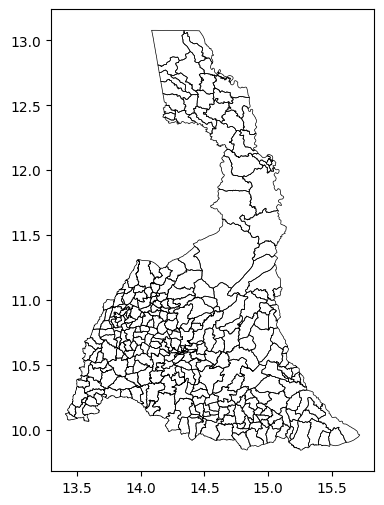

In [12]:
cameroon_extnord_lv3.plot(facecolor="none", edgecolor='black', lw=0.5, figsize=(6,6), color='none')

In [13]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

In [14]:
df_grid_extnord_d4 = create_grid(empty_gdf, cameroon_extnord_gdf, col_municipal='GID0', dimension=4)

e:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\../utils\modules.py:34: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()


In [15]:
df_grid_extnord_d4.head()

,geometry,centers,GID0,x,y
0,"POLYGON ((13.51256 10.11460, 13.51256 10.15054...",POINT (13.4943230295934 10.132571084602414),extreme-nord,13.49432,10.13257
1,"POLYGON ((13.51256 10.15054, 13.51256 10.18647...",POINT (13.4943230295934 10.168504467802842),extreme-nord,13.49432,10.16850
2,"POLYGON ((13.51256 10.22240, 13.51256 10.25834...",POINT (13.4943230295934 10.240371234203701),extreme-nord,13.49432,10.24037
3,"POLYGON ((13.54904 10.11460, 13.54904 10.15054...",POINT (13.5308034622307 10.132571084602414),extreme-nord,13.53080,10.13257
4,"POLYGON ((13.54904 10.15054, 13.54904 10.18647...",POINT (13.5308034622307 10.168504467802842),extreme-nord,13.53080,10.16850


In [16]:
df_grid_extnord_d4.shape

(1964, 5)

<Axes: >

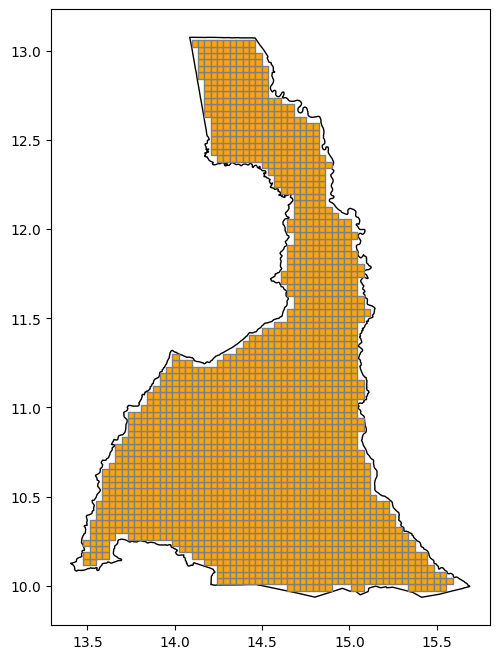

In [17]:
ax = cameroon_extnord_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
df_grid_extnord_d4.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [18]:
df_grid_extnord_d4.set_geometry('centers', inplace=True)
df_grid_extnord_d4.set_crs(epsg=4326, inplace=True)

,geometry,centers,GID0,x,y
0,"POLYGON ((13.51256 10.11460, 13.51256 10.15054...",POINT (13.49432 10.13257),extreme-nord,13.49432,10.13257
1,"POLYGON ((13.51256 10.15054, 13.51256 10.18647...",POINT (13.49432 10.16850),extreme-nord,13.49432,10.16850
2,"POLYGON ((13.51256 10.22240, 13.51256 10.25834...",POINT (13.49432 10.24037),extreme-nord,13.49432,10.24037
3,"POLYGON ((13.54904 10.11460, 13.54904 10.15054...",POINT (13.53080 10.13257),extreme-nord,13.53080,10.13257
4,"POLYGON ((13.54904 10.15054, 13.54904 10.18647...",POINT (13.53080 10.16850),extreme-nord,13.53080,10.16850
...,...,...,...,...,...
1959,"POLYGON ((15.51899 10.04274, 15.51899 10.07867...",POINT (15.50075 10.06070),extreme-nord,15.50075,10.06070
1960,"POLYGON ((15.55547 9.97087, 15.55547 10.00680,...",POINT (15.53723 9.98884),extreme-nord,15.53723,9.98884
1961,"POLYGON ((15.55547 10.00680, 15.55547 10.04274...",POINT (15.53723 10.02477),extreme-nord,15.53723,10.02477
1962,"POLYGON ((15.55547 10.04274, 15.55547 10.07867...",POINT (15.53723 10.06070),extreme-nord,15.53723,10.06070


In [19]:
cameroon_extnord_grid = gpd.sjoin(df_grid_extnord_d4, cameroon_extnord_lv3, how='left', op='within')

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\IPython\core\interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [20]:
cameroon_extnord_grid.head()

,geometry,centers,GID0_left,x,y,index_right,GID3,GID2,GID1,GID0_right
0,"POLYGON ((13.51256 10.11460, 13.51256 10.15054...",POINT (13.49432 10.13257),extreme-nord,13.49432,10.13257,11,tchevi,bourha,mayo-tsanaga,extreme nord
1,"POLYGON ((13.51256 10.15054, 13.51256 10.18647...",POINT (13.49432 10.16850),extreme-nord,13.49432,10.16850,11,tchevi,bourha,mayo-tsanaga,extreme nord
2,"POLYGON ((13.51256 10.22240, 13.51256 10.25834...",POINT (13.49432 10.24037),extreme-nord,13.49432,10.24037,9,bourha,bourha,mayo-tsanaga,extreme nord
3,"POLYGON ((13.54904 10.11460, 13.54904 10.15054...",POINT (13.53080 10.13257),extreme-nord,13.53080,10.13257,11,tchevi,bourha,mayo-tsanaga,extreme nord
4,"POLYGON ((13.54904 10.15054, 13.54904 10.18647...",POINT (13.53080 10.16850),extreme-nord,13.53080,10.16850,11,tchevi,bourha,mayo-tsanaga,extreme nord


In [21]:
cameroon_extnord_grid.dropna(inplace=True)

In [22]:
final_grid = cameroon_extnord_grid[['x', 'y', 'GID0_right', 'GID1', 'GID2', 'GID3', 'centers', 'geometry']].copy()
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'GID0_right': "GID0"}, inplace=True)
final_grid.sort_values(by=['x', 'y', 'GID3'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

<Axes: >

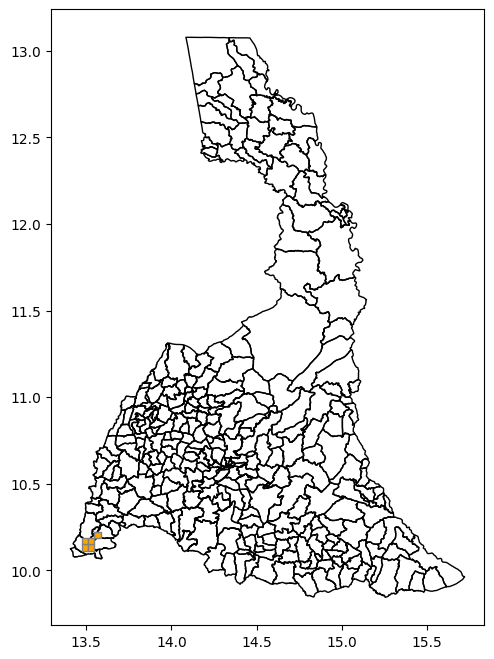

In [23]:
ax = cameroon_extnord_lv3.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
final_grid[final_grid['GID3'] == 'tchevi'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [24]:
final_grid

,x,y,GID0,GID1,GID2,GID3,centers,geometry
0,13.49432,10.13257,extreme nord,mayo-tsanaga,bourha,tchevi,POINT (13.49432 10.13257),"POLYGON ((13.51256 10.11460, 13.51256 10.15054..."
1,13.49432,10.16850,extreme nord,mayo-tsanaga,bourha,tchevi,POINT (13.49432 10.16850),"POLYGON ((13.51256 10.15054, 13.51256 10.18647..."
2,13.49432,10.24037,extreme nord,mayo-tsanaga,bourha,bourha,POINT (13.49432 10.24037),"POLYGON ((13.51256 10.22240, 13.51256 10.25834..."
3,13.53080,10.13257,extreme nord,mayo-tsanaga,bourha,tchevi,POINT (13.53080 10.13257),"POLYGON ((13.54904 10.11460, 13.54904 10.15054..."
4,13.53080,10.16850,extreme nord,mayo-tsanaga,bourha,tchevi,POINT (13.53080 10.16850),"POLYGON ((13.54904 10.15054, 13.54904 10.18647..."
...,...,...,...,...,...,...,...,...
1959,15.50075,10.06070,extreme nord,mayo-danay,guere,nouldaina,POINT (15.50075 10.06070),"POLYGON ((15.51899 10.04274, 15.51899 10.07867..."
1960,15.53723,9.98884,extreme nord,mayo-danay,guere,polgue,POINT (15.53723 9.98884),"POLYGON ((15.55547 9.97087, 15.55547 10.00680,..."
1961,15.53723,10.02477,extreme nord,mayo-danay,guere,nouldaina,POINT (15.53723 10.02477),"POLYGON ((15.55547 10.00680, 15.55547 10.04274..."
1962,15.53723,10.06070,extreme nord,mayo-danay,guere,nouldaina,POINT (15.53723 10.06070),"POLYGON ((15.55547 10.04274, 15.55547 10.07867..."


In [25]:
print(f'Shape of final_grid: {final_grid.GID3.unique().shape}')
print(f'Shape of cameroon_nord_lv3: {cameroon_extnord_lv3.GID3.unique().shape}')

Shape of final_grid: (288,)
Shape of cameroon_nord_lv3: (315,)


In [26]:
diff = list(set(cameroon_extnord_lv3.GID3.unique().tolist()) - set(final_grid.GID3.unique().tolist()))
print(f'Difference is: {len(diff)}')
print(f'Missing GIDs are: {diff}') 

Difference is: 27
Missing GIDs are: ['golonghini', 'gangalang', 'ouro tchede', 'kengola', 'mora', 'kobro', 'domayo 2', 'boukoula', 'pagui', 'dougoi 2', 'madana', 'vounaloum', 'amchidire', 'maboudji', 'dongrosse', 'domayo djarma', 'dougoi 1', 'lopere', 'dougoi 3', 'vele', 'fotokol', 'djafga', 'gamboura 2', 'magoumaz', 'koza 2', 'godigong', 'parpar']


In [27]:
missing_GIDs_d4 = cameroon_extnord_lv3[cameroon_extnord_lv3.GID3.isin(diff)].copy()
missing_GIDs_d4.reset_index(drop=True, inplace=True)

In [28]:
missing_GIDs_d4.head()

,GID3,GID2,GID1,GID0,geometry
0,boukoula,bourha,mayo-tsanaga,extreme nord,"POLYGON ((13.46996 10.19503, 13.47019 10.19477..."
1,parpar,kousseri,logone et chari,extreme nord,"POLYGON ((15.02908 12.07528, 15.02918 12.07514..."
2,golonghini,guidiguis,mayo-kani,extreme nord,"POLYGON ((14.83232 9.94649, 14.83268 9.94657, ..."
3,dongrosse,guidiguis,mayo-kani,extreme nord,"POLYGON ((14.88527 10.07945, 14.88530 10.07926..."
4,vounaloum,yagoua,mayo-danay,extreme nord,"POLYGON ((15.24890 10.43704, 15.24939 10.43701..."


In [29]:
df_grid_extnord_d2= create_grid(empty_gdf, missing_GIDs_d4, col_municipal='GID0', dimension=2)

e:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\../utils\modules.py:34: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()


In [30]:
df_grid_extnord_d2.head()

,geometry,centers,GID0,x,y
0,"POLYGON ((13.46038 10.14060, 13.46038 10.15857...",POINT (13.451254292802991 10.149586778000588),extreme nord,13.45125,10.14959
1,"POLYGON ((13.46038 10.15857, 13.46038 10.17654...",POINT (13.451254292802991 10.1675534696008),extreme nord,13.45125,10.16755
2,"POLYGON ((13.47863 10.12264, 13.47863 10.14060...",POINT (13.469504058657321 10.131620086400371),extreme nord,13.46950,10.13162
3,"POLYGON ((13.47863 10.14060, 13.47863 10.15857...",POINT (13.469504058657321 10.149586778000588),extreme nord,13.46950,10.14959
4,"POLYGON ((13.47863 10.15857, 13.47863 10.17654...",POINT (13.469504058657321 10.1675534696008),extreme nord,13.46950,10.16755


In [31]:
df_grid_extnord_d2.shape

(41, 5)

<Axes: >

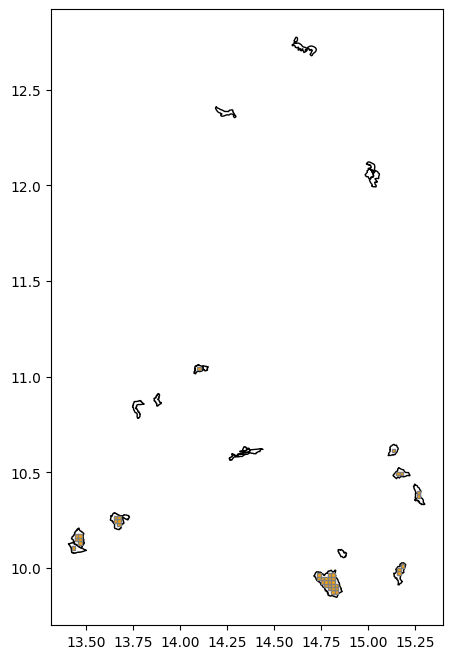

In [32]:
ax = missing_GIDs_d4.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
df_grid_extnord_d2.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [33]:
df_grid_extnord_d2.set_geometry('centers', inplace=True)
df_grid_extnord_d2.set_crs(epsg=4326, inplace=True)

,geometry,centers,GID0,x,y
0,"POLYGON ((13.46038 10.14060, 13.46038 10.15857...",POINT (13.45125 10.14959),extreme nord,13.45125,10.14959
1,"POLYGON ((13.46038 10.15857, 13.46038 10.17654...",POINT (13.45125 10.16755),extreme nord,13.45125,10.16755
2,"POLYGON ((13.47863 10.12264, 13.47863 10.14060...",POINT (13.46950 10.13162),extreme nord,13.46950,10.13162
3,"POLYGON ((13.47863 10.14060, 13.47863 10.15857...",POINT (13.46950 10.14959),extreme nord,13.46950,10.14959
4,"POLYGON ((13.47863 10.15857, 13.47863 10.17654...",POINT (13.46950 10.16755),extreme nord,13.46950,10.16755
5,"POLYGON ((14.74942 9.93661, 14.74942 9.95458, ...",POINT (14.74030 9.94560),extreme nord,14.74030,9.94560
6,"POLYGON ((14.74942 9.95458, 14.74942 9.97255, ...",POINT (14.74030 9.96356),extreme nord,14.74030,9.96356
7,"POLYGON ((14.76766 9.91865, 14.76766 9.93661, ...",POINT (14.75854 9.92763),extreme nord,14.75854,9.92763
8,"POLYGON ((14.76766 9.93661, 14.76766 9.95458, ...",POINT (14.75854 9.94560),extreme nord,14.75854,9.94560
9,"POLYGON ((14.78589 9.90068, 14.78589 9.91865, ...",POINT (14.77677 9.90966),extreme nord,14.77677,9.90966


In [34]:
cameroon_extnord_second_grid = gpd.sjoin(df_grid_extnord_d2, missing_GIDs_d4, how='left', op='within')

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\IPython\core\interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [35]:
cameroon_extnord_second_grid.head()

,geometry,centers,GID0_left,x,y,index_right,GID3,GID2,GID1,GID0_right
0,"POLYGON ((13.46038 10.14060, 13.46038 10.15857...",POINT (13.45125 10.14959),extreme nord,13.45125,10.14959,0,boukoula,bourha,mayo-tsanaga,extreme nord
1,"POLYGON ((13.46038 10.15857, 13.46038 10.17654...",POINT (13.45125 10.16755),extreme nord,13.45125,10.16755,0,boukoula,bourha,mayo-tsanaga,extreme nord
2,"POLYGON ((13.47863 10.12264, 13.47863 10.14060...",POINT (13.46950 10.13162),extreme nord,13.46950,10.13162,0,boukoula,bourha,mayo-tsanaga,extreme nord
3,"POLYGON ((13.47863 10.14060, 13.47863 10.15857...",POINT (13.46950 10.14959),extreme nord,13.46950,10.14959,0,boukoula,bourha,mayo-tsanaga,extreme nord
4,"POLYGON ((13.47863 10.15857, 13.47863 10.17654...",POINT (13.46950 10.16755),extreme nord,13.46950,10.16755,0,boukoula,bourha,mayo-tsanaga,extreme nord


In [36]:
cameroon_extnord_second_grid.dropna(inplace=True)

In [37]:
cameroon_extnord_second_grid = cameroon_extnord_second_grid[['x', 'y', 'GID0_right', 'GID1', 'GID2', 'GID3', 'centers', 'geometry']].copy()
cameroon_extnord_second_grid.set_geometry('geometry', inplace=True)
cameroon_extnord_second_grid.rename(columns={'GID0_right': "GID0"}, inplace=True)
cameroon_extnord_second_grid.sort_values(by=['x', 'y', 'GID3'], inplace = True)
cameroon_extnord_second_grid.reset_index(drop=True, inplace=True)

In [39]:
cameroon_extnord_second_grid.head()

,x,y,GID0,GID1,GID2,GID3,centers,geometry
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,POINT (13.43483 10.10446),"POLYGON ((13.44396 10.09547, 13.44396 10.11344..."
1,13.45125,10.14959,extreme nord,mayo-tsanaga,bourha,boukoula,POINT (13.45125 10.14959),"POLYGON ((13.46038 10.14060, 13.46038 10.15857..."
2,13.45125,10.16755,extreme nord,mayo-tsanaga,bourha,boukoula,POINT (13.45125 10.16755),"POLYGON ((13.46038 10.15857, 13.46038 10.17654..."
3,13.46950,10.13162,extreme nord,mayo-tsanaga,bourha,boukoula,POINT (13.46950 10.13162),"POLYGON ((13.47863 10.12264, 13.47863 10.14060..."
4,13.46950,10.14959,extreme nord,mayo-tsanaga,bourha,boukoula,POINT (13.46950 10.14959),"POLYGON ((13.47863 10.14060, 13.47863 10.15857..."


In [40]:
final_grid = pd.concat([final_grid, cameroon_extnord_second_grid], ignore_index=True)

In [41]:
print(f'Shape of final_grid: {final_grid.GID3.unique().shape}')
print(f'Shape of cameroon_nord_lv3: {cameroon_extnord_lv3.GID3.unique().shape}')

Shape of final_grid: (297,)
Shape of cameroon_nord_lv3: (315,)


In [42]:
diff = list(set(cameroon_extnord_lv3.GID3.unique().tolist()) - set(final_grid.GID3.unique().tolist()))
print(f'Difference is: {len(diff)}')
print(f'Missing GIDs are: {diff}') 

Difference is: 18
Missing GIDs are: ['fotokol', 'dougoi 2', 'madana', 'dougoi 1', 'ouro tchede', 'kengola', 'amchidire', 'mora', 'dongrosse', 'domayo djarma', 'magoumaz', 'domayo 2', 'kobro', 'koza 2', 'lopere', 'dougoi 3', 'pagui', 'parpar']


In [43]:
missing_GIDs_d2 = cameroon_extnord_lv3[cameroon_extnord_lv3.GID3.isin(diff)].copy()
missing_GIDs_d2.reset_index(drop=True, inplace=True)

In [45]:
missing_GIDs_d2.head()

,GID3,GID2,GID1,GID0,geometry
0,parpar,kousseri,logone et chari,extreme nord,"POLYGON ((15.02908 12.07528, 15.02918 12.07514..."
1,dongrosse,guidiguis,mayo-kani,extreme nord,"POLYGON ((14.88527 10.07945, 14.88530 10.07926..."
2,koza 2,koza,mayo-tsanaga,extreme nord,"POLYGON ((13.88877 10.91190, 13.88884 10.91109..."
3,domayo djarma,maroua 1,diamare,extreme nord,"POLYGON ((14.33703 10.59964, 14.33723 10.59969..."
4,domayo 2,maroua 1,diamare,extreme nord,"POLYGON ((14.34125 10.59121, 14.34125 10.59121..."


In [46]:
df_grid_extnord_d1= create_grid(empty_gdf, missing_GIDs_d2, col_municipal='GID0', dimension=1)

e:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\../utils\modules.py:34: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()


In [48]:
df_grid_extnord_d1.head()

,geometry,centers,GID0,x,y
0,"POLYGON ((14.85898 10.08100, 14.85898 10.08998...",POINT (14.854414433052021 10.085492009300415),extreme nord,14.85441,10.08549
1,"POLYGON ((14.86810 10.06303, 14.86810 10.07202...",POINT (14.863537883086657 10.0675253177002),extreme nord,14.86354,10.06753
2,"POLYGON ((14.86810 10.07202, 14.86810 10.08100...",POINT (14.863537883086657 10.076508663500306),extreme nord,14.86354,10.07651
3,"POLYGON ((14.87722 10.06303, 14.87722 10.07202...",POINT (14.872661333121291 10.0675253177002),extreme nord,14.87266,10.06753
4,"POLYGON ((13.88107 10.87347, 13.88107 10.88245...",POINT (13.87649662777943 10.87796176530042),extreme nord,13.87650,10.87796


In [50]:
df_grid_extnord_d1.shape

(59, 5)

<Axes: >

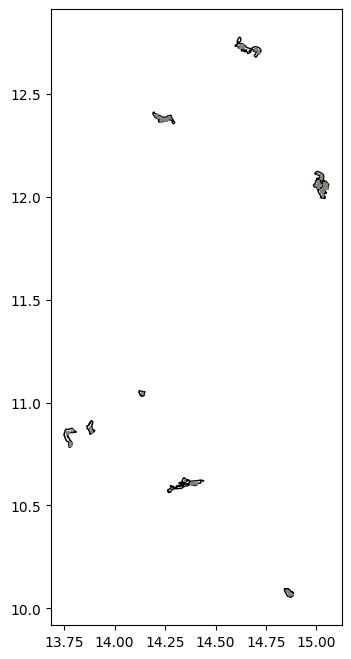

In [51]:
ax = missing_GIDs_d2.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
df_grid_extnord_d1.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [52]:
df_grid_extnord_d1.set_geometry('centers', inplace=True)
df_grid_extnord_d1.set_crs(epsg=4326, inplace=True)

,geometry,centers,GID0,x,y
0,"POLYGON ((14.85898 10.08100, 14.85898 10.08998...",POINT (14.85441 10.08549),extreme nord,14.85441,10.08549
1,"POLYGON ((14.86810 10.06303, 14.86810 10.07202...",POINT (14.86354 10.06753),extreme nord,14.86354,10.06753
2,"POLYGON ((14.86810 10.07202, 14.86810 10.08100...",POINT (14.86354 10.07651),extreme nord,14.86354,10.07651
3,"POLYGON ((14.87722 10.06303, 14.87722 10.07202...",POINT (14.87266 10.06753),extreme nord,14.87266,10.06753
4,"POLYGON ((13.88107 10.87347, 13.88107 10.88245...",POINT (13.87650 10.87796),extreme nord,13.87650,10.87796
5,"POLYGON ((13.89022 10.85550, 13.89022 10.86449...",POINT (13.88564 10.86000),extreme nord,13.88564,10.86000
6,"POLYGON ((14.38239 10.60617, 14.38239 10.61515...",POINT (14.37782 10.61066),extreme nord,14.37782,10.61066
7,"POLYGON ((14.39152 10.60617, 14.39152 10.61515...",POINT (14.38696 10.61066),extreme nord,14.38696,10.61066
8,"POLYGON ((14.40066 10.60617, 14.40066 10.61515...",POINT (14.39609 10.61066),extreme nord,14.39609,10.61066
9,"POLYGON ((14.40980 10.60617, 14.40980 10.61515...",POINT (14.40523 10.61066),extreme nord,14.40523,10.61066


In [53]:
cameroon_extnord_third_grid = gpd.sjoin(df_grid_extnord_d1, missing_GIDs_d2, how='left', op='within')

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\IPython\core\interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [54]:
cameroon_extnord_third_grid.head()

,geometry,centers,GID0_left,x,y,index_right,GID3,GID2,GID1,GID0_right
0,"POLYGON ((14.85898 10.08100, 14.85898 10.08998...",POINT (14.85441 10.08549),extreme nord,14.85441,10.08549,1,dongrosse,guidiguis,mayo-kani,extreme nord
1,"POLYGON ((14.86810 10.06303, 14.86810 10.07202...",POINT (14.86354 10.06753),extreme nord,14.86354,10.06753,1,dongrosse,guidiguis,mayo-kani,extreme nord
2,"POLYGON ((14.86810 10.07202, 14.86810 10.08100...",POINT (14.86354 10.07651),extreme nord,14.86354,10.07651,1,dongrosse,guidiguis,mayo-kani,extreme nord
3,"POLYGON ((14.87722 10.06303, 14.87722 10.07202...",POINT (14.87266 10.06753),extreme nord,14.87266,10.06753,1,dongrosse,guidiguis,mayo-kani,extreme nord
4,"POLYGON ((13.88107 10.87347, 13.88107 10.88245...",POINT (13.87650 10.87796),extreme nord,13.87650,10.87796,2,koza 2,koza,mayo-tsanaga,extreme nord


In [55]:
cameroon_extnord_third_grid.dropna(inplace=True)

In [56]:
cameroon_extnord_third_grid = cameroon_extnord_third_grid[['x', 'y', 'GID0_right', 'GID1', 'GID2', 'GID3', 'centers', 'geometry']].copy()
cameroon_extnord_third_grid.set_geometry('geometry', inplace=True)
cameroon_extnord_third_grid.rename(columns={'GID0_right': "GID0"}, inplace=True)
cameroon_extnord_third_grid.sort_values(by=['x', 'y', 'GID3'], inplace = True)
cameroon_extnord_third_grid.reset_index(drop=True, inplace=True)

In [57]:
cameroon_extnord_third_grid.head()

,x,y,GID0,GID1,GID2,GID3,centers,geometry
0,13.76208,10.84962,extreme nord,mayo-tsanaga,mokolo,magoumaz,POINT (13.76208 10.84962),"POLYGON ((13.76665 10.84513, 13.76665 10.85411..."
1,13.76208,10.85860,extreme nord,mayo-tsanaga,mokolo,magoumaz,POINT (13.76208 10.85860),"POLYGON ((13.76665 10.85411, 13.76665 10.86309..."
2,13.77122,10.85860,extreme nord,mayo-tsanaga,mokolo,magoumaz,POINT (13.77122 10.85860),"POLYGON ((13.77580 10.85411, 13.77580 10.86309..."
3,13.78037,10.79572,extreme nord,mayo-tsanaga,mokolo,magoumaz,POINT (13.78037 10.79572),"POLYGON ((13.78494 10.79123, 13.78494 10.80021..."
4,13.78037,10.80470,extreme nord,mayo-tsanaga,mokolo,magoumaz,POINT (13.78037 10.80470),"POLYGON ((13.78494 10.80021, 13.78494 10.80919..."


In [58]:
final_grid = pd.concat([final_grid, cameroon_extnord_third_grid], ignore_index=True)

In [59]:
print(f'Shape of final_grid: {final_grid.GID3.unique().shape}')
print(f'Shape of cameroon_nord_lv3: {cameroon_extnord_lv3.GID3.unique().shape}')

Shape of final_grid: (308,)
Shape of cameroon_nord_lv3: (315,)


In [60]:
diff = list(set(cameroon_extnord_lv3.GID3.unique().tolist()) - set(final_grid.GID3.unique().tolist()))
print(f'Difference is: {len(diff)}')
print(f'Missing GIDs are: {diff}') 

Difference is: 7
Missing GIDs are: ['dougoi 2', 'dougoi 1', 'ouro tchede', 'domayo djarma', 'domayo 2', 'lopere', 'parpar']


In [61]:
missing_GIDs_d1 = cameroon_extnord_lv3[cameroon_extnord_lv3.GID3.isin(diff)].copy()
missing_GIDs_d1.reset_index(drop=True, inplace=True)

In [62]:
missing_GIDs_d1

,GID3,GID2,GID1,GID0,geometry
0,parpar,kousseri,logone et chari,extreme nord,"POLYGON ((15.02908 12.07528, 15.02918 12.07514..."
1,domayo djarma,maroua 1,diamare,extreme nord,"POLYGON ((14.33703 10.59964, 14.33723 10.59969..."
2,domayo 2,maroua 1,diamare,extreme nord,"POLYGON ((14.34125 10.59121, 14.34125 10.59121..."
3,dougoi 2,maroua 3,diamare,extreme nord,"POLYGON ((14.36411 10.60541, 14.36397 10.60561..."
4,ouro tchede,maroua 1,diamare,extreme nord,"POLYGON ((14.28231 10.59508, 14.28278 10.59486..."
5,lopere,maroua 2,diamare,extreme nord,"POLYGON ((14.33308 10.61527, 14.33322 10.61525..."
6,dougoi 1,maroua 3,diamare,extreme nord,"POLYGON ((14.34390 10.60452, 14.34465 10.60236..."


In [63]:
missing_GIDs_d1["centers"] = missing_GIDs_d1.geometry.centroid

C:\Users\dimit\AppData\Local\Temp\ipykernel_36248\1981699749.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  missing_GIDs_d1["centers"] = missing_GIDs_d1.geometry.centroid


In [64]:
missing_GIDs_d1

,GID3,GID2,GID1,GID0,geometry,centers
0,parpar,kousseri,logone et chari,extreme nord,"POLYGON ((15.02908 12.07528, 15.02918 12.07514...",POINT (15.02603 12.07277)
1,domayo djarma,maroua 1,diamare,extreme nord,"POLYGON ((14.33703 10.59964, 14.33723 10.59969...",POINT (14.31991 10.59552)
2,domayo 2,maroua 1,diamare,extreme nord,"POLYGON ((14.34125 10.59121, 14.34125 10.59121...",POINT (14.32358 10.58888)
3,dougoi 2,maroua 3,diamare,extreme nord,"POLYGON ((14.36411 10.60541, 14.36397 10.60561...",POINT (14.35849 10.61191)
4,ouro tchede,maroua 1,diamare,extreme nord,"POLYGON ((14.28231 10.59508, 14.28278 10.59486...",POINT (14.28169 10.57956)
5,lopere,maroua 2,diamare,extreme nord,"POLYGON ((14.33308 10.61527, 14.33322 10.61525...",POINT (14.32987 10.60998)
6,dougoi 1,maroua 3,diamare,extreme nord,"POLYGON ((14.34390 10.60452, 14.34465 10.60236...",POINT (14.34881 10.60032)


<Axes: >

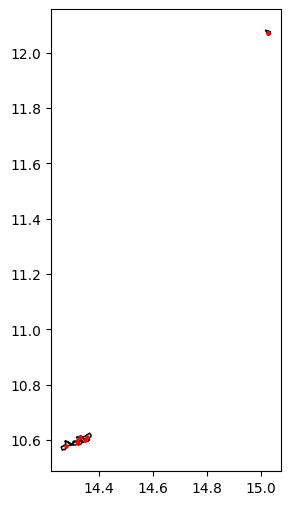

In [65]:
ax = missing_GIDs_d1.plot(edgecolor='black', facecolor='none', figsize=(6, 6))
missing_GIDs_d1['centers'].plot(ax=ax, color='red', markersize=5)

In [66]:
missing_GIDs_d1["x"] = missing_GIDs_d1["centers"].x
missing_GIDs_d1["y"] = missing_GIDs_d1["centers"].y
missing_GIDs_d1 = missing_GIDs_d1[['x', 'y', 'GID0', 'GID1', 'GID2', 'GID3', 'centers', 'geometry']]

In [67]:
missing_GIDs_d1.head()

,x,y,GID0,GID1,GID2,GID3,centers,geometry
0,15.026032,12.072768,extreme nord,logone et chari,kousseri,parpar,POINT (15.02603 12.07277),"POLYGON ((15.02908 12.07528, 15.02918 12.07514..."
1,14.319909,10.595522,extreme nord,diamare,maroua 1,domayo djarma,POINT (14.31991 10.59552),"POLYGON ((14.33703 10.59964, 14.33723 10.59969..."
2,14.323584,10.588880,extreme nord,diamare,maroua 1,domayo 2,POINT (14.32358 10.58888),"POLYGON ((14.34125 10.59121, 14.34125 10.59121..."
3,14.358492,10.611912,extreme nord,diamare,maroua 3,dougoi 2,POINT (14.35849 10.61191),"POLYGON ((14.36411 10.60541, 14.36397 10.60561..."
4,14.281691,10.579557,extreme nord,diamare,maroua 1,ouro tchede,POINT (14.28169 10.57956),"POLYGON ((14.28231 10.59508, 14.28278 10.59486..."


In [68]:
final_grid = pd.concat([final_grid, missing_GIDs_d1], ignore_index=True)

In [70]:
print(f'Shape of final_grid: {final_grid.GID3.unique().shape}')
print(f'Shape of cameroon_extnord_lv3: {cameroon_extnord_lv3.GID3.unique().shape}')

Shape of final_grid: (315,)
Shape of cameroon_extnord_lv3: (315,)


In [71]:
final_grid.sort_values(by=['x', 'y', 'GID1', 'GID2', 'GID3'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)
final_grid.drop(columns=['centers'], inplace=True)
final_grid

,x,y,GID0,GID1,GID2,GID3,geometry
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,"POLYGON ((13.44396 10.09547, 13.44396 10.11344..."
1,13.45125,10.14959,extreme nord,mayo-tsanaga,bourha,boukoula,"POLYGON ((13.46038 10.14060, 13.46038 10.15857..."
2,13.45125,10.16755,extreme nord,mayo-tsanaga,bourha,boukoula,"POLYGON ((13.46038 10.15857, 13.46038 10.17654..."
3,13.46950,10.13162,extreme nord,mayo-tsanaga,bourha,boukoula,"POLYGON ((13.47863 10.12264, 13.47863 10.14060..."
4,13.46950,10.14959,extreme nord,mayo-tsanaga,bourha,boukoula,"POLYGON ((13.47863 10.14060, 13.47863 10.15857..."
...,...,...,...,...,...,...,...
2066,15.50075,10.06070,extreme nord,mayo-danay,guere,nouldaina,"POLYGON ((15.51899 10.04274, 15.51899 10.07867..."
2067,15.53723,9.98884,extreme nord,mayo-danay,guere,polgue,"POLYGON ((15.55547 9.97087, 15.55547 10.00680,..."
2068,15.53723,10.02477,extreme nord,mayo-danay,guere,nouldaina,"POLYGON ((15.55547 10.00680, 15.55547 10.04274..."
2069,15.53723,10.06070,extreme nord,mayo-danay,guere,nouldaina,"POLYGON ((15.55547 10.04274, 15.55547 10.07867..."


In [72]:
final_grid.drop(columns='geometry').to_csv(f'../data/CM_ExtNord_Grid.csv', encoding=enc, index = False)
final_grid.to_file(f'../data/CM_ExtNord_Grid.shp', encoding = 'utf-8')